# Evaluasi Model Heart Disease Prediction

Notebook ini mengevaluasi model Neural Network yang sudah dilatih pada notebook `03_model_training_indhira.ipynb` menggunakan data testing hasil preprocessing.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from tensorflow.keras.models import load_model
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "TensorFlow belum terinstall. Jalankan: pip install -r requirements.txt"
    ) from error

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load Model dan Data Testing

In [9]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "processed_data"
MODEL_PATH = PROJECT_ROOT / "model" / "heart_disease_nn_model.h5"
DATASET_PATH = PROJECT_ROOT / "dataset" / "heart.csv"

required_files = [
    PROCESSED_DIR / "X_test_scaled.csv",
    PROCESSED_DIR / "y_test.csv",
    MODEL_PATH,
]

missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "File berikut belum ditemukan. Jalankan preprocessing dan training terlebih dahulu:\n"
        + "\n".join(missing_files)
    )

X_test = pd.read_csv(PROCESSED_DIR / "X_test_scaled.csv")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns")
model = load_model(MODEL_PATH)

print("Model dan data testing berhasil dimuat.")
print("Lokasi model       :", MODEL_PATH)
print("Jumlah data testing:", len(y_test))
print("Jumlah fitur       :", X_test.shape[1])

Model dan data testing berhasil dimuat.
Lokasi model       : d:\kuliah\semester 4\Keahlian Artificial\Kelompok\model\heart_disease_nn_model.h5
Jumlah data testing: 61
Jumlah fitur       : 13


## 2. Prediksi Data Testing

In [10]:
THRESHOLD = 0.5

y_pred_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_prob >= THRESHOLD).astype(int)

preview_prediksi = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Probability": y_pred_prob,
    "Prediction": y_pred,
})

preview_prediksi.head(10)

,Actual,Probability,Prediction
0,0,0.035726,0
1,0,0.787708,1
2,0,0.005732,0
3,0,0.425501,0
4,0,0.957823,1
5,0,0.012180,0
6,1,0.933908,1
7,0,0.002508,0
8,1,0.996241,1
9,0,0.536297,1


## 3. Metrik Evaluasi

In [11]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_prob),
}

hasil_evaluasi = (
    pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
    .assign(Percentage=lambda df: df["Value"].map(lambda value: f"{value:.2%}"))
)

hasil_evaluasi

,Metric,Value,Percentage
0,Accuracy,0.803279,80.33%
1,Precision,0.818182,81.82%
2,Recall,0.818182,81.82%
3,F1 Score,0.818182,81.82%
4,ROC-AUC,0.843074,84.31%


In [12]:
print("Classification Report")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Tidak Berisiko", "Berisiko"],
        zero_division=0,
    )
)

Classification Report
                precision    recall  f1-score   support

Tidak Berisiko       0.79      0.79      0.79        28
      Berisiko       0.82      0.82      0.82        33

      accuracy                           0.80        61
     macro avg       0.80      0.80      0.80        61
  weighted avg       0.80      0.80      0.80        61



## 4. Visualisasi Evaluasi

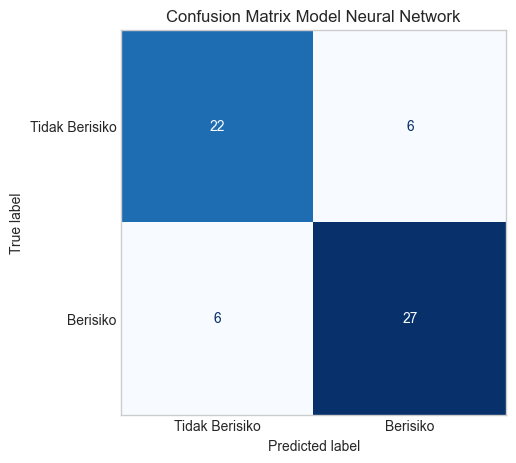

In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Berisiko", "Berisiko"],
)
display.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix Model Neural Network")
ax.grid(False)
plt.show()

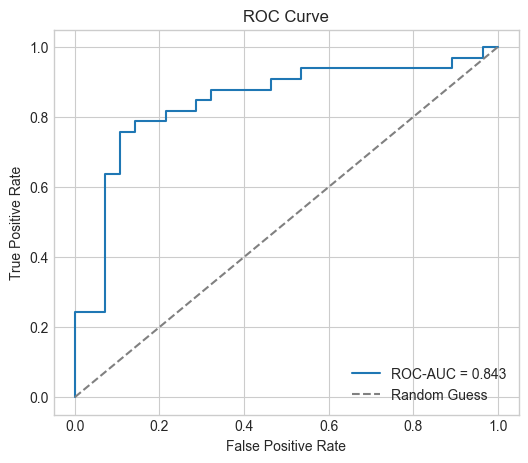

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## 5. Contoh Prediksi Pasien Baru

Karena scaler tidak disimpan pada notebook preprocessing, scaler direkonstruksi ulang dari dataset asli dengan parameter split yang sama.

In [15]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset asli tidak ditemukan: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH).drop_duplicates().reset_index(drop=True)
X = df.drop(columns=["target"])
y = df["target"]

X_train_raw, _, y_train_raw, _ = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
scaler.fit(X_train_raw)

print("Scaler berhasil direkonstruksi dari data training.")

Scaler berhasil direkonstruksi dari data training.


In [16]:
sample_patient = pd.DataFrame(
    [[55, 1, 0, 130, 250, 0, 1, 150, 0, 1.0, 2, 0, 2]],
    columns=X.columns,
)

sample_patient_scaled = scaler.transform(sample_patient)
sample_probability = model.predict(sample_patient_scaled, verbose=0).ravel()[0]
sample_prediction = int(sample_probability >= THRESHOLD)

print(f"Probabilitas risiko penyakit jantung: {sample_probability:.2%}")

if sample_prediction == 1:
    print("Prediksi: Pasien memiliki risiko penyakit jantung.")
else:
    print("Prediksi: Pasien tidak memiliki risiko penyakit jantung.")

Probabilitas risiko penyakit jantung: 64.97%
Prediksi: Pasien memiliki risiko penyakit jantung.


## 6. Kesimpulan

In [17]:
print("KESIMPULAN MODEL")
print("=" * 60)
print(f"Accuracy : {metrics['Accuracy']:.2%}")
print(f"Precision: {metrics['Precision']:.2%}")
print(f"Recall   : {metrics['Recall']:.2%}")
print(f"F1 Score : {metrics['F1 Score']:.2%}")
print(f"ROC-AUC  : {metrics['ROC-AUC']:.2%}")
print()
print(
    "Model Neural Network dapat digunakan sebagai sistem pendukung keputusan "
    "untuk membantu identifikasi awal risiko penyakit jantung. Hasil prediksi "
    "tetap perlu divalidasi oleh tenaga medis karena model hanya belajar dari "
    "pola data historis."
)

KESIMPULAN MODEL
Accuracy : 80.33%
Precision: 81.82%
Recall   : 81.82%
F1 Score : 81.82%
ROC-AUC  : 84.31%

Model Neural Network dapat digunakan sebagai sistem pendukung keputusan untuk membantu identifikasi awal risiko penyakit jantung. Hasil prediksi tetap perlu divalidasi oleh tenaga medis karena model hanya belajar dari pola data historis.
